<a href="https://colab.research.google.com/github/sauravv-kunwar/100-days-of-ML/blob/main/Voting_Ensemble_Classifier_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Voting Ensemble: A Detailed Note

Voting Ensemble is a powerful and intuitive technique in machine learning used to improve the overall predictive performance and robustness of models. It achieves this by combining predictions from multiple individual machine learning models.

### Key Concepts:

1.  **Definition**: A voting ensemble aggregates predictions from several base estimators (individual models) to arrive at a final prediction. It is a form of ensemble learning, where the wisdom of the crowd is leveraged.

2.  **How it Works (Classification)**:
    *   Each individual model in the ensemble makes its own prediction for a given input.
    *   For classification tasks, the most common approach is to use a **majority vote**. The class label that receives the most votes from the individual models is chosen as the final prediction.
    *   **Hard Voting**: Counts the predicted class labels and selects the one with the most votes.
    *   **Soft Voting**: Averages the predicted probabilities for each class across all models and then selects the class with the highest average probability. Soft voting often performs better than hard voting if the models are well-calibrated.

3.  **How it Works (Regression)**:
    *   For regression tasks, the final prediction is typically the **average** (mean) of the predictions made by all individual models in the ensemble.

4.  **Benefits**:
    *   **Improved Accuracy**: Often outperforms individual models, especially when the base models are diverse.
    *   **Reduced Overfitting**: By combining multiple models, the ensemble tends to generalize better to unseen data.
    *   **Increased Robustness**: Less susceptible to the weaknesses or biases of any single model.
    *   **Simplicity**: Conceptually straightforward and relatively easy to implement.

5.  **Diversity is Crucial**: The success of a voting ensemble heavily relies on the **diversity** of its constituent models.
    *   Models that make different types of errors complement each other.
    *   Diversity can be achieved by:
        *   Using different types of algorithms (e.g., Logistic Regression, Decision Tree, SVM).
        *   Training the same algorithm on different subsets of the data (e.g., Bagging).
        *   Using different features for different models.

### Example Use Cases:

*   **Classification**: Predicting customer churn, image classification, spam detection.
*   **Regression**: Stock price prediction, housing price estimation.

### Limitations:

*   **Increased Complexity**: While simple in concept, training and managing multiple models can be more computationally intensive and time-consuming than a single model.
*   **Interpretability**: Ensembles are generally less interpretable than single models, making it harder to understand *why* a particular prediction was made.

In [9]:
from sklearn.datasets import load_iris
import numpy as np
import pandas as pd


iris = load_iris()

# Create a DataFrame from the iris data
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
# Add the target column
df['target'] = iris.target
# Map target integers to their names for better readability
df['target_names'] = df['target'].map(lambda x: iris.target_names[x])

print("Features:", iris.feature_names)
print("Target:", iris.target_names)

Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target: ['setosa' 'versicolor' 'virginica']


In [10]:
display(df.head())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_names
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [11]:
print(df.shape)

(150, 6)


In [12]:
from sklearn.preprocessing import LabelEncoder

In [13]:
encoder = LabelEncoder()
df['target_names'] = encoder.fit_transform(df['target_names'])

In [14]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_names
0,5.1,3.5,1.4,0.2,0,0
1,4.9,3.0,1.4,0.2,0,0
2,4.7,3.2,1.3,0.2,0,0
3,4.6,3.1,1.5,0.2,0,0
4,5.0,3.6,1.4,0.2,0,0


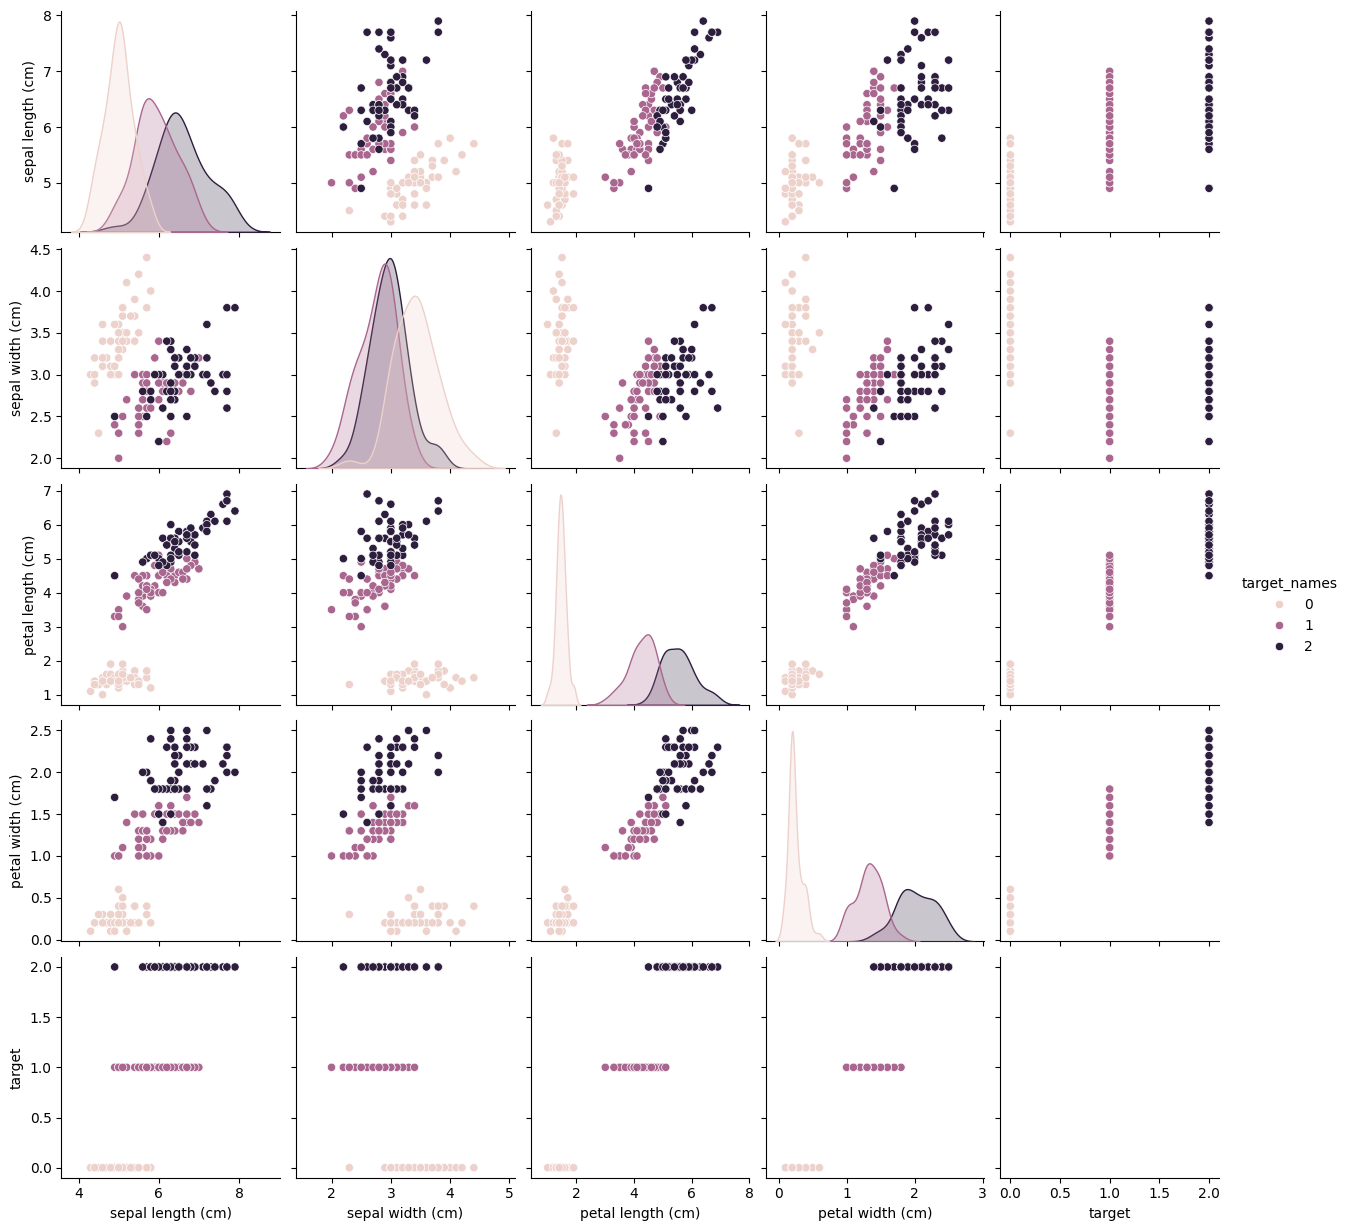

In [15]:
import seaborn as sns
sns.pairplot(df,hue = 'target_names')

In [16]:
new_df = df[df['target_names'] != 0] [['sepal length (cm)', 'sepal width (cm)', 'target_names']]

In [17]:
new_df.head()

,sepal length (cm),sepal width (cm),target_names
50,7.0,3.2,1
51,6.4,3.2,1
52,6.9,3.1,1
53,5.5,2.3,1
54,6.5,2.8,1


In [18]:
new_df.shape

(100, 3)

In [25]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

In [27]:
clf1 = LogisticRegression()
clf2 = KNeighborsClassifier()
clf3 = RandomForestClassifier()


In [28]:
estimators = [('lr',clf1),('rf',clf3),('knn',clf2)]

In [30]:
for estimator in estimators:
    x = cross_val_score(estimator[1],X,y,cv=10,scoring='accuracy')
    print(estimator[0],np.round(np.mean(x),2))

lr 0.81
rf 0.73
knn 0.76


In [31]:
from sklearn.ensemble import VotingClassifier

In [32]:
# Hard Voting

vc = VotingClassifier(estimators = estimators, voting = 'hard')  ## default is hard
x = cross_val_score(vc,X,y,cv=10,scoring='accuracy')
print(np.round(np.mean(x),2))

0.77


In [33]:
## Soft Voting
vc1 = VotingClassifier(estimators=estimators,voting='soft')
x = cross_val_score(vc1,X,y,cv=10,scoring='accuracy')
print(np.round(np.mean(x),2))

0.77


In [34]:
## Weighted Voting
for i in range(1,4):
    for j in range(1,4):
        for k in range(1,4):
            vc = VotingClassifier(estimators=estimators,voting='soft',weights=[i,j,k])
            x = cross_val_score(vc,X,y,cv=10,scoring='accuracy')
            print("for i={},j={},k={}".format(i,j,k),np.round(np.mean(x),2))


for i=1,j=1,k=1 0.76
for i=1,j=1,k=2 0.77
for i=1,j=1,k=3 0.75
for i=1,j=2,k=1 0.75
for i=1,j=2,k=2 0.75
for i=1,j=2,k=3 0.75
for i=1,j=3,k=1 0.73
for i=1,j=3,k=2 0.75
for i=1,j=3,k=3 0.75
for i=2,j=1,k=1 0.79
for i=2,j=1,k=2 0.77
for i=2,j=1,k=3 0.77
for i=2,j=2,k=1 0.76
for i=2,j=2,k=2 0.76
for i=2,j=2,k=3 0.75
for i=2,j=3,k=1 0.74
for i=2,j=3,k=2 0.75
for i=2,j=3,k=3 0.76
for i=3,j=1,k=1 0.81
for i=3,j=1,k=2 0.79
for i=3,j=1,k=3 0.79
for i=3,j=2,k=1 0.79
for i=3,j=2,k=2 0.77
for i=3,j=2,k=3 0.77
for i=3,j=3,k=1 0.75
for i=3,j=3,k=2 0.75
for i=3,j=3,k=3 0.75


In [35]:
# Classifir of Same Algorithm
from sklearn.svm import SVC
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=1000, n_features=20, n_informative=15, n_redundant=5, random_state=2)

svm1 = SVC(probability=True, kernel='poly', degree=1)
svm2 = SVC(probability=True, kernel='poly', degree=2)
svm3 = SVC(probability=True, kernel='poly', degree=3)
svm4 = SVC(probability=True, kernel='poly', degree=4)
svm5 = SVC(probability=True, kernel='poly', degree=5)

estimators = [('svm1',svm1),('svm2',svm2),('svm3',svm3),('svm4',svm4),('svm5',svm5)]

for estimator in estimators:
    x = cross_val_score(estimator[1],X,y,cv=10,scoring='accuracy')
    print(estimator[0],np.round(np.mean(x),2))

svm1 0.85
svm2 0.85
svm3 0.89
svm4 0.81
svm5 0.86


In [36]:
vc1 = VotingClassifier(estimators=estimators,voting='soft')
x = cross_val_score(vc1,X,y,cv=10,scoring='accuracy')
print(np.round(np.mean(x),2))

0.93
